# Part 4: Content Segmentation and Clustering
This notebook clusters the platform contents via structural numeric attributes using K-Means and profiles those segments via PCA dimension reduction.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv("netflix_featured.csv")

In [ ]:
# Target specific structural attributes
features = ["release_year", "duration_num", "genre_count", "cast_count", "title_length"]
cluster_features = df[features].copy().fillna(df[features].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

In [9]:
# Fit KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
print(df["cluster"].value_counts().sort_index())

cluster
0    2005
1    3955
2     580
3    2267
Name: count, dtype: int64


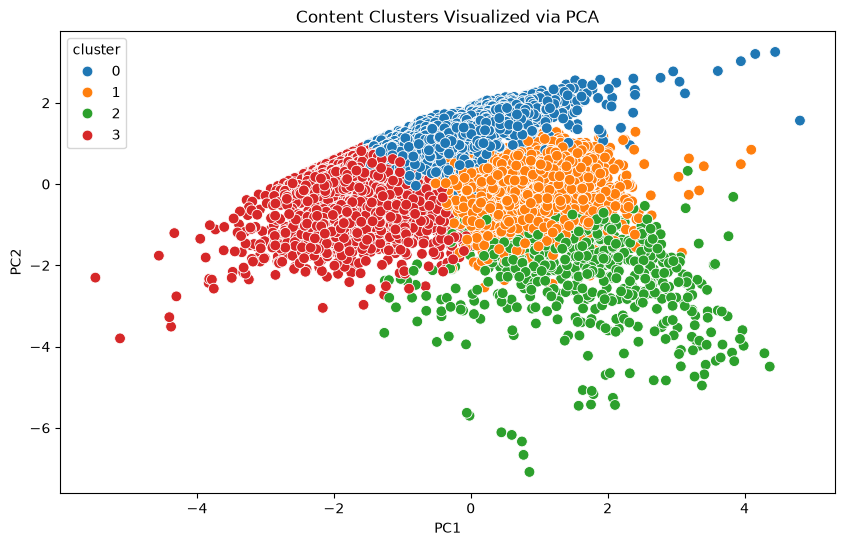

In [10]:
# PCA Projections for Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"].values#"Copy the cluster numbers from df into a new cluster column in pca_df

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", s=60)#s=60-means size of each dot
plt.title("Content Clusters Visualized via PCA")
plt.show()

In [11]:
# Final distribution exports
df.to_csv("netflix_cleaned_featured.csv", index=False)
print("Final portfolio output saved!")

Final portfolio output saved!
